In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install numpy scikit-learn
!pip install -q torch_geometric
!pip install -q class_resolver
!pip3 install pymatting
!pip install opencv-python

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 44.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.7/54.7 kB 2.6 MB/s eta 0:00:00


In [1]:
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, roc_auc_score, log_loss
import torch
import torch.nn as nn
import torch.nn.functional as nnFn
import torch.optim as optim
import numpy as np
import random
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from torch.utils.data import TensorDataset, DataLoader, Subset
from torch_geometric.data import Data

/home/snu/.local/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import numpy as np

feature_path = "/home/snu/Downloads/liver_dino_features.npy"

label_path = "/home/snu/Downloads/liver_dino_labels.npy"

features = np.load(
    feature_path
).astype(np.float32)

y_labels = np.load(
    label_path
).astype(np.int64)

print("Feature shape:", features.shape)

print("Label shape:", y_labels.shape)

print("\nClass distribution:")

unique, counts = np.unique(
    y_labels,
    return_counts=True
)

for cls, cnt in zip(unique, counts):

    print(f"Class {cls}: {cnt}")

Feature shape: (635, 768)
Label shape: (635,)

Class distribution:
Class 0: 200
Class 1: 435


In [3]:
scaler = StandardScaler()
X = scaler.fit_transform(features)
y = y_labels

In [4]:
# 20 stratified splits (10% train, 90% test per fold)
sss = StratifiedShuffleSplit(n_splits=20, test_size=0.9, random_state=42)

In [5]:
# Metric storage
accuracies, precisions, recalls, f1_scores, losses = [], [], [], [], []

In [6]:
all_y_true = []
all_y_proba = []
all_fpr = []
all_tpr = []
all_auc = []
# Loop over folds
for fold, (train_idx, test_idx) in enumerate(sss.split(X, y)):
    print(f"\nTraining fold {fold + 1}")

    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    rf = RandomForestClassifier(n_estimators=200, max_depth=50, random_state=42)
    rf.fit(X_train, y_train)

    y_pred = rf.predict(X_test)
    y_pred_proba = rf.predict_proba(X_test)[:, 1]

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    loss = log_loss(y_test, y_pred_proba)
    auc_score = roc_auc_score(y_test, y_pred_proba)

    accuracies.append(accuracy)
    precisions.append(precision)
    recalls.append(recall)
    f1_scores.append(f1)
    losses.append(loss)
    all_y_true.extend(y_test)
    all_y_proba.extend(y_pred_proba)

    fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
    all_fpr.append(fpr)
    all_tpr.append(tpr)
    all_auc.append(auc_score)

    print(f"Accuracy: {accuracy:.4f} | Precision: {precision:.4f} | Recall: {recall:.4f} | F1: {f1:.4f} | Loss: {loss:.4f} | AUC: {auc_score:.4f}")

# Final average results
print("\nAverage Results across 20 folds:")
print(f"Accuracy: {np.mean(accuracies):.4f} ± {np.std(accuracies):.4f}")
print(f"Precision: {np.mean(precisions):.4f} ± {np.std(precisions):.4f}")
print(f"Recall: {np.mean(recalls):.4f} ± {np.std(recalls):.4f}")
print(f"F1 Score: {np.mean(f1_scores):.4f} ± {np.std(f1_scores):.4f}")
print(f"Cross-Entropy Loss: {np.mean(losses):.4f} ± {np.std(losses):.4f}")
print(f"Average AUC: {np.mean(all_auc):.4f} ± {np.std(all_auc):.4f}")


Training fold 1
Accuracy: 0.7150 | Precision: 0.7215 | Recall: 0.9515 | F1: 0.8207 | Loss: 0.5422 | AUC: 0.7659

Training fold 2
Accuracy: 0.7465 | Precision: 0.7800 | Recall: 0.8776 | F1: 0.8259 | Loss: 0.5109 | AUC: 0.8120

Training fold 3
Accuracy: 0.7325 | Precision: 0.7444 | Recall: 0.9286 | F1: 0.8263 | Loss: 0.5144 | AUC: 0.7933

Training fold 4
Accuracy: 0.7220 | Precision: 0.7316 | Recall: 0.9388 | F1: 0.8223 | Loss: 0.5205 | AUC: 0.7837

Training fold 5
Accuracy: 0.7290 | Precision: 0.7570 | Recall: 0.8903 | F1: 0.8183 | Loss: 0.5416 | AUC: 0.7630

Training fold 6
Accuracy: 0.7430 | Precision: 0.7495 | Recall: 0.9388 | F1: 0.8335 | Loss: 0.5189 | AUC: 0.8124

Training fold 7
Accuracy: 0.7343 | Precision: 0.7419 | Recall: 0.9388 | F1: 0.8288 | Loss: 0.5132 | AUC: 0.8132

Training fold 8
Accuracy: 0.7465 | Precision: 0.7726 | Recall: 0.8929 | F1: 0.8284 | Loss: 0.5087 | AUC: 0.7996

Training fold 9
Accuracy: 0.7255 | Precision: 0.7308 | Recall: 0.9490 | F1: 0.8257 | Loss: 0.53

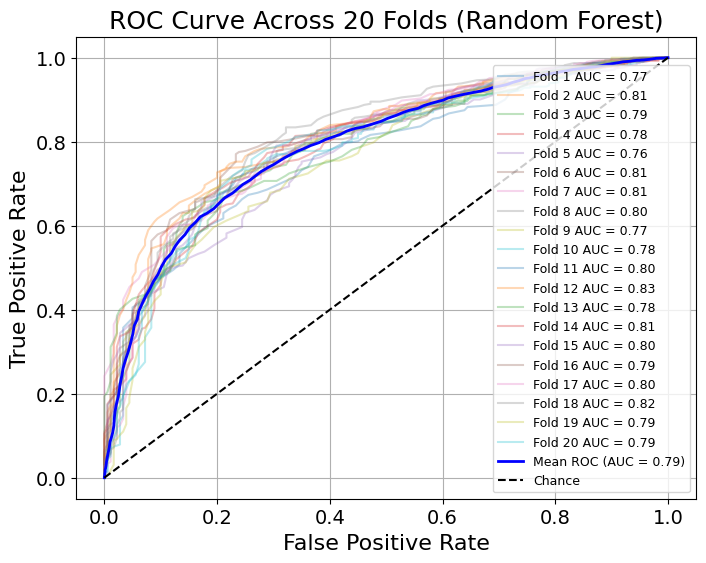

In [7]:
plt.figure(figsize=(8, 6))

for i in range(len(all_fpr)):
    plt.plot(all_fpr[i], all_tpr[i], alpha=0.3, label=f"Fold {i+1} AUC = {all_auc[i]:.2f}")

# Average ROC Curve
fpr_avg, tpr_avg, _ = roc_curve(all_y_true, all_y_proba)
auc_avg = roc_auc_score(all_y_true, all_y_proba)
plt.plot(fpr_avg, tpr_avg, color='blue', lw=2, label=f"Mean ROC (AUC = {auc_avg:.2f})")

# Diagonal line
plt.plot([0, 1], [0, 1], 'k--', label="Chance")
plt.xlabel("False Positive Rate", fontsize=16)
plt.ylabel("True Positive Rate", fontsize=16)
plt.title("ROC Curve Across 20 Folds (Random Forest)", fontsize=18)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.legend(loc="lower right", fontsize=9)
plt.grid(True)